# AI Impact on Students — Exploratory Data Analysis

A data analysis project exploring how AI tool usage affects academic 
performance, burnout risk, and skill retention among undergraduate students.

**Dataset:** 50,000 student records (42,570 undergraduates after filtering)  
**Tools:** Python, Pandas, Seaborn, Matplotlib  
**Author:** Sergio Boccassini

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Phase 1 — Data Exploration

Initial exploration of the dataset: dimensions, data types, missing values, 
and distribution of categorical variables.

In [2]:
df = pd.read_csv('ai_student_impact_dataset.csv')
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
print(df.shape)
print(df.dtypes)
df.info()

(50000, 16)
Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 n

In [4]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [5]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


### Categorical Variables Distribution

In [6]:
print(df['Major_Category'].value_counts())
print(df['Year_of_Study'].value_counts())
print(df['Primary_Use_Case'].value_counts())
print(df['Prompt_Engineering_Skill'].value_counts())
print(df['Burnout_Risk_Level'].value_counts())

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


## Phase 2 — Feature Engineering

Two new columns added to support the analysis:
- **GPA_Delta**: difference between Post and Pre semester GPA, measuring academic improvement
- **AI_Usage_Level**: students segmented into Light / Moderate / Heavy users based on Weekly_GenAI_Hours quartiles

In [7]:
df_ug = df[df['Year_of_Study'] != 'Graduate']
df_ug['GPA_Delta'] = df_ug['Post_Semester_GPA'] - df_ug['Pre_Semester_GPA']

In [8]:
df_ug['AI_Usage_Level'] = pd.qcut(df_ug['Weekly_GenAI_Hours'], q=3, labels=['Light', 'Moderate', 'Heavy'])

## Analysis

Four questions explored to understand the relationship between AI usage 
and academic outcomes.

### Question 1 — Does AI usage actually improve GPA?

In [9]:
gpa_by_usage = df_ug.groupby('AI_Usage_Level')['GPA_Delta'].mean()
gpa_by_usage

AI_Usage_Level
Light       0.181859
Moderate    0.210932
Heavy       0.191282
Name: GPA_Delta, dtype: float64

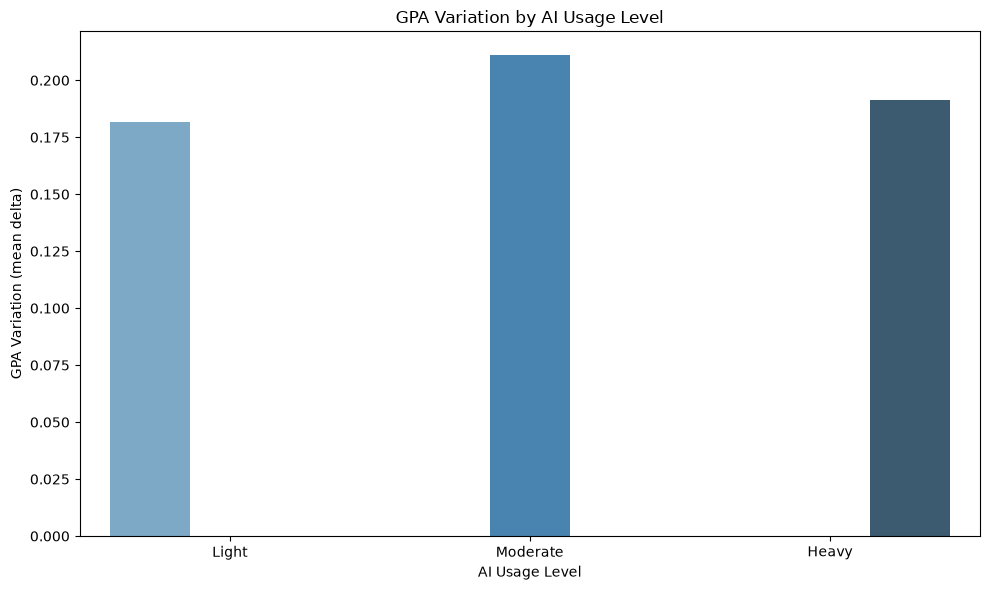

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=gpa_by_usage.index,
    y=gpa_by_usage.values,
    hue=gpa_by_usage.index,
    palette='Blues_d',
    legend=False,
    width=0.8
)

plt.title('GPA Variation by AI Usage Level')
plt.xlabel('AI Usage Level')
plt.ylabel('GPA Variation (mean delta)')
plt.tight_layout()
plt.show()

### Conclusion

AI does help GPA, but only when used mindfully. Students who use AI moderately 
show the highest GPA improvement, especially when combined with strong prompt 
engineering skills. Heavy users show greater burnout risk, higher exam anxiety, 
and lower skill retention — suggesting that delegating too much to AI comes at 
a real cost.

> *"AI works with you, not for you."*

### Question 2 — Does the benefit depend on the faculty?

In [11]:
gpa_by_major = df_ug.groupby(['Major_Category', 'AI_Usage_Level'])['GPA_Delta'].mean().reset_index()

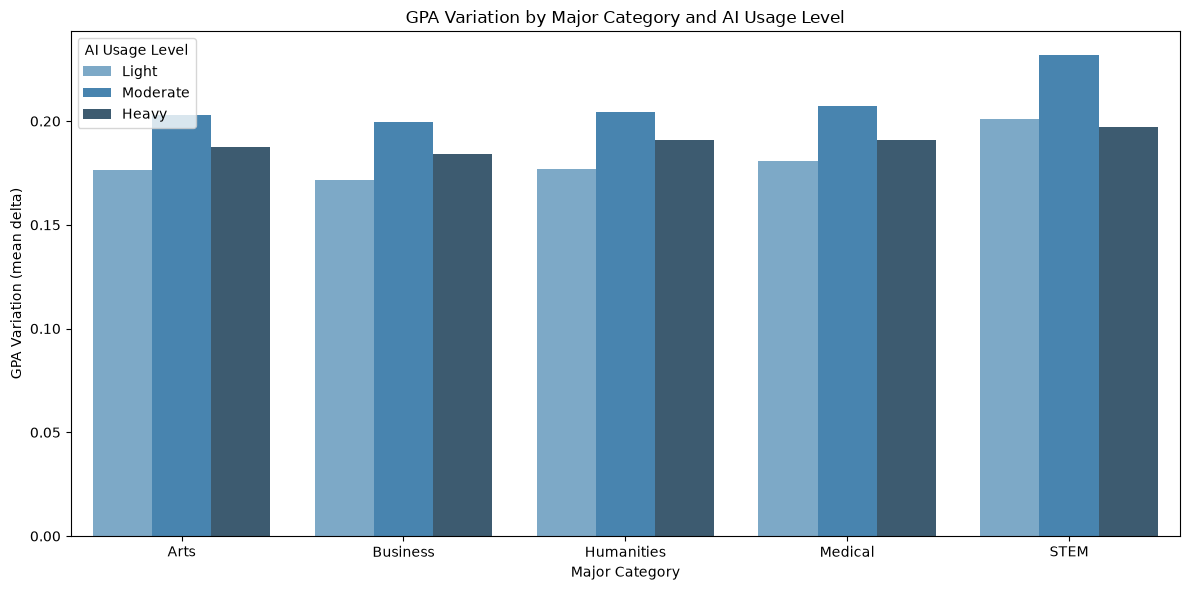

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=gpa_by_major,
    x='Major_Category',
    y='GPA_Delta',
    hue='AI_Usage_Level',
    palette='Blues_d'
)

plt.title('GPA Variation by Major Category and AI Usage Level')
plt.xlabel('Major Category')
plt.ylabel('GPA Variation (mean delta)')
plt.legend(title='AI Usage Level')
plt.tight_layout()
plt.show()

### Conclusion

All faculties benefit from AI, but not equally. STEM students show the highest 
GPA improvement (Moderate: +0.231), followed by Medical and Humanities. 
The pattern holds across all majors: moderate use consistently outperforms 
heavy use.

### Question 3 — What is the cost of heavy AI usage?

In [13]:
burnout_data = df_ug.groupby(['AI_Usage_Level', 'Burnout_Risk_Level']).size().reset_index(name='count')

In [14]:
burnout_pivot = burnout_data.pivot(
    index='AI_Usage_Level',
    columns='Burnout_Risk_Level',
    values='count'
)


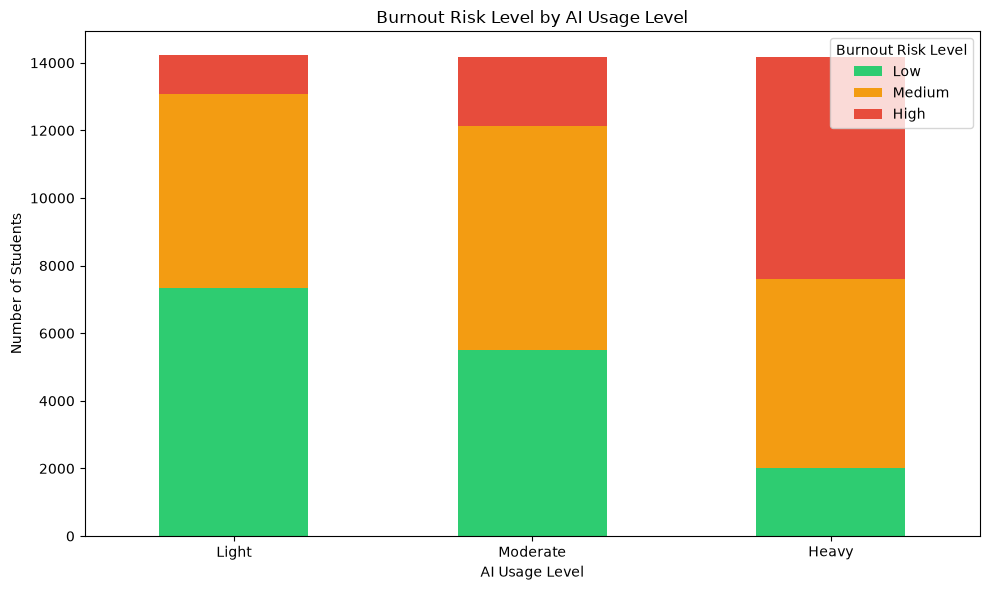

In [15]:
burnout_pivot[['Low', 'Medium', 'High']].plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    figsize=(10, 6)
)

plt.title('Burnout Risk Level by AI Usage Level')
plt.xlabel('AI Usage Level')
plt.ylabel('Number of Students')
plt.legend(title='Burnout Risk Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
df_ug.groupby('AI_Usage_Level')['Anxiety_Level_During_Exams'].describe()

,count,mean,std,min,25%,50%,75%,max
AI_Usage_Level,,,,,,,,
Light,14220.0,3.818636,1.946634,1.0,2.0,4.0,5.0,10.0
Moderate,14173.0,4.013688,1.989553,1.0,2.0,4.0,5.0,10.0
Heavy,14177.0,5.002257,2.307149,1.0,3.0,5.0,7.0,10.0


In [17]:
df_ug.groupby('AI_Usage_Level')['Perceived_AI_Dependency'].describe()

,count,mean,std,min,25%,50%,75%,max
AI_Usage_Level,,,,,,,,
Light,14220.0,2.537553,1.277540,1.0,1.0,2.0,3.0,7.0
Moderate,14173.0,3.121499,1.389722,1.0,2.0,3.0,4.0,8.0
Heavy,14177.0,4.862101,1.861670,1.0,4.0,5.0,6.0,10.0


In [18]:
df_ug.groupby('AI_Usage_Level')['Skill_Retention_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
AI_Usage_Level,,,,,,,,
Light,14220.0,75.490461,12.906980,30.18,66.55,75.52,84.62,100.0
Moderate,14173.0,76.571162,12.869408,30.70,67.72,76.62,85.71,100.0
Heavy,14177.0,74.437606,14.018021,10.78,65.15,74.82,84.29,100.0


### Conclusion

AI usage has a real cost when taken too far. Heavy users show nearly 6x more 
high burnout risk than light users, higher exam anxiety, and lower skill 
retention scores — including extreme cases close to zero. Students who delegate 
too much to AI arrive at exams underprepared.

> *"AI works with you, not for you."*

### Question 4 — Does prompt engineering skill make a difference?

In [19]:
gpa_by_skill = df_ug.groupby(['Prompt_Engineering_Skill', 'AI_Usage_Level'])['GPA_Delta'].mean().reset_index()

In [20]:
skill_pivot = gpa_by_skill.pivot(
    index='AI_Usage_Level',
    columns='Prompt_Engineering_Skill',
    values='GPA_Delta'
)

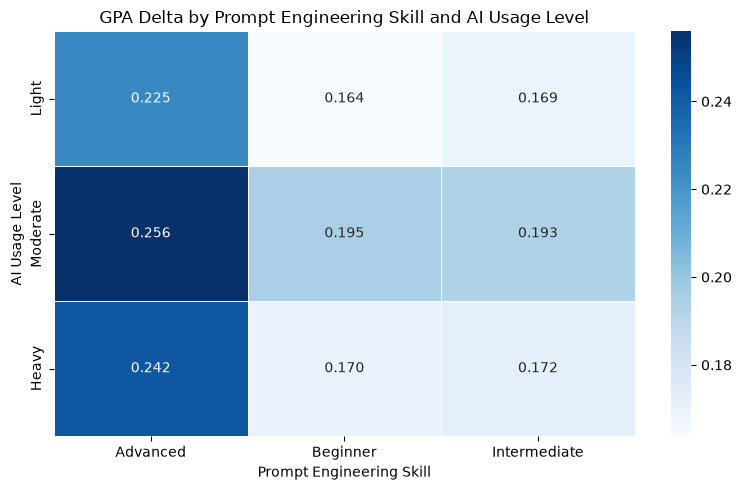

In [21]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    skill_pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('GPA Delta by Prompt Engineering Skill and AI Usage Level')
plt.xlabel('Prompt Engineering Skill')
plt.ylabel('AI Usage Level')
plt.tight_layout()
plt.show()

### Conclusion

Skill beats quantity. An Advanced user with light AI usage (GPA Delta: 0.224) 
outperforms a Beginner with heavy usage (0.169). Hours spent using AI matter 
less than knowing how to use it effectively.

## Final Thoughts

This analysis confirms that AI is a powerful academic tool — but only when used 
strategically. The data consistently points to one conclusion: moderate, 
skilled use of AI outperforms heavy, undirected use across all faculties and 
all metrics.

Key takeaways:
- **Moderate use** beats heavy use on GPA improvement across all faculties
- **STEM students** benefit the most in absolute terms
- **Heavy use** correlates with burnout, anxiety, and lower skill retention
- **Prompt engineering skill** matters more than hours spent using AI

*This project was built as part of a personal portfolio to document a career 
transition into data analysis and AI. The dataset is synthetic and sourced 
from Kaggle.*